In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid")
%matplotlib inline

df = pd.read_csv("Customer Churn new 2.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,747,15787619,Hsieh,844,France,Male,18,2,160980.03,145936.28,0
1,1620,15770309,McDonald,656,France,Male,18,10,151762.74,127014.32,0
2,1679,15569178,Kharlamov,570,France,Female,18,4,82767.42,71811.90,0
3,2022,15795519,Vasiliev,716,Germany,Female,18,3,128743.80,197322.13,0
4,2137,15621893,Bellucci,727,France,Male,18,4,133550.67,46941.41,0


In [2]:
print(df.isnull().sum())
print("\n", df.dtypes)
print("\nChurn rate:", df['Exited'].mean().round(4))

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
EstimatedSalary    0
Exited             0
dtype: int64

 RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
EstimatedSalary    float64
Exited               int64
dtype: object

Churn rate: 0.2037


In [3]:
#Checking missing values ,data types and churn rate 

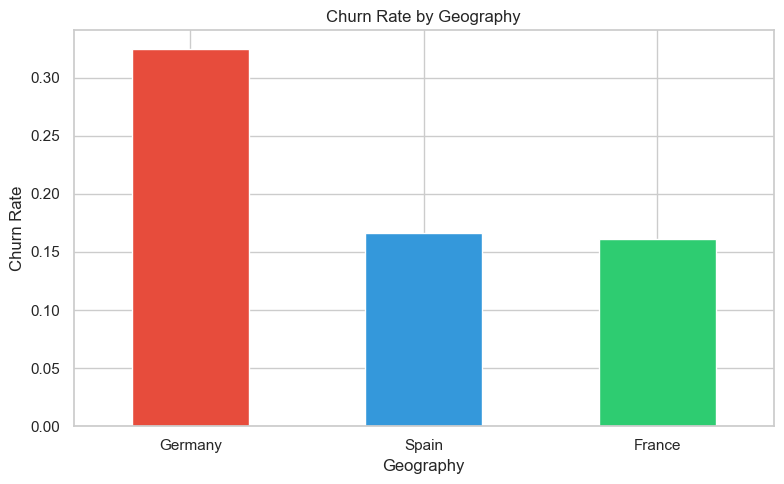

In [4]:
churn_geo = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
churn_geo.plot(kind='bar', color=['#e74c3c','#3498db','#2ecc71'], figsize=(8,5))
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Churn by Geography 

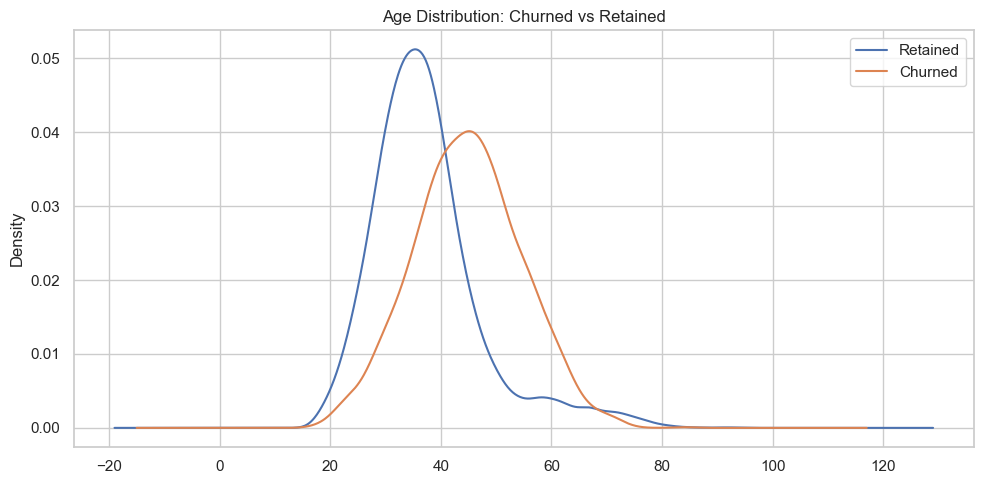

In [6]:
fig, ax = plt.subplots(figsize=(10,5))
df[df['Exited']==0]['Age'].plot(kind='kde', label='Retained', ax=ax)
df[df['Exited']==1]['Age'].plot(kind='kde', label='Churned', ax=ax)
plt.title('Age Distribution: Churned vs Retained')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
#Seperates retained and churned customers , plots their age distributions on the same chart,churned customers skew older than retained customers

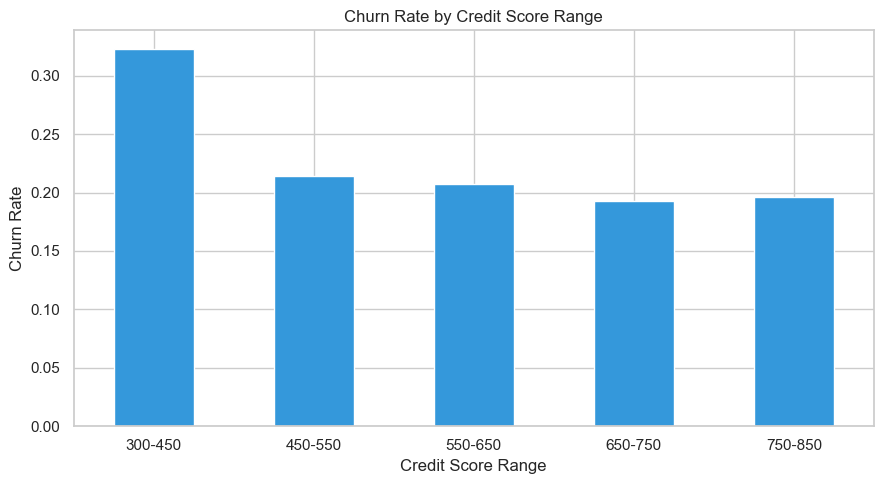

CreditScore_Range
300-450    0.323
450-550    0.214
550-650    0.208
650-750    0.192
750-850    0.196
Name: Exited, dtype: float64


In [8]:
df['CreditScore_Range'] = pd.cut(df['CreditScore'], 
                                  bins=[300, 450, 550, 650, 750, 850],
                                  labels=['300-450', '450-550', '550-650', '650-750', '750-850'])

churn_credit = df.groupby('CreditScore_Range', observed=True)['Exited'].mean()

churn_credit.plot(kind='bar', color='#3498db', figsize=(9,5))
plt.title('Churn Rate by Credit Score Range')
plt.ylabel('Churn Rate')
plt.xlabel('Credit Score Range')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(churn_credit.round(3))

In [9]:
#Converts raw credit score into buckets , calculate churn rate for each bucket

In [10]:
from scipy import stats  

female_churn = df[df['Gender'] == 'Female']['Exited']
male_churn = df[df['Gender'] == 'Male']['Exited']

t_stat, p_value = stats.ttest_ind(female_churn, male_churn)
print(f"P-value: {p_value}")

P-value: 1.2585045636809457e-26


In [11]:
#Splits churn labels by gender , runs a t-test to check weather difference are significant , p value is very small

In [12]:
germany_churn = df[df['Geography'] == 'Germany']['Exited']
others_churn = df[df['Geography'] != 'Germany']['Exited']

t_stat, p_value = stats.ttest_ind(germany_churn, others_churn)
print(f"Geography p-value: {p_value}")

Geography p-value: 2.05953728250839e-68


In [13]:
retained_age = df[df['Exited'] == 0]['Age']
churned_age = df[df['Exited'] == 1]['Age']

t_stat, p_value = stats.ttest_ind(retained_age, churned_age)
print(f"Age p-value: {p_value}")

Age p-value: 1.2399313093427736e-186


In [14]:
avg_balance_churned = df[df['Exited'] == 1]['Balance'].mean()
total_churned = df['Exited'].sum()
revenue_lost = total_churned * avg_balance_churned * 0.02 

print(f"Customers lost: {total_churned}")
print(f"Estimated annual revenue lost: ${revenue_lost:,.0f}")

Customers lost: 2037
Estimated annual revenue lost: $3,711,762


In [15]:
#Finds avg balance among churned customers , counts no of churned customers

In [16]:
df.groupby('Gender')['Exited'].mean()

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

In [17]:
df.groupby('Exited')['Age'].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

In [18]:
df.groupby('Exited')['Balance'].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

In [19]:
df.groupby(['Geography', 'Gender'])['Exited'].mean()

Geography  Gender
France     Female    0.203450
           Male      0.127134
Germany    Female    0.375524
           Male      0.278116
Spain      Female    0.212121
           Male      0.131124
Name: Exited, dtype: float64

In [20]:
high_risk = df[
    (df['Geography'] == 'Germany') &
    (df['Gender'] == 'Female') &
    (df['Age'] > 40)
]

high_risk['Exited'].mean()

np.float64(0.576171875)

In [21]:
#Filters the dataframe down to one specific segment 

In [22]:
#Spliting data into training and testing sets
from sklearn.model_selection import train_test_split

X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']]
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Standardizes features so they are on comparable scales
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Training a model so it evaluates it on test data
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)

#Predict
y_pred = model.predict(X_test_scaled)

#Evaluate
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Precision: 0.3702127659574468
Recall: 0.6365853658536585
F1: 0.46816143497757845


In [23]:
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['IsActiveByAge'] = df['Age'] * df['Tenure']
df[['BalanceSalaryRatio', 'IsActiveByAge']].head()

,BalanceSalaryRatio,IsActiveByAge
0,1.103077,36
1,1.194838,180
2,1.152543,72
3,0.652452,54
4,2.844990,72


In [24]:
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary',
        'BalanceSalaryRatio', 'IsActiveByAge']]

In [25]:
#Adding a new feature .